# Cañadata — exploración de datos

Este notebook es de **lectura**: lo recorres antes de la primera sesión para anclarte en el dataset que usaremos durante todo el taller.

Si tu memoria de EDA está oxidada, no pasa nada — la idea aquí no es enseñarte EDA otra vez, sino que llegues a S1 sabiendo cómo se ven los datos de Cañadata.

Si te entra el gusanillo, al final hay retos opcionales marcados con 🚀.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Encuentra la raíz del proyecto, ya estés en pre_class/ o en el root
ROOT = Path.cwd()
if ROOT.name == "pre_class":
    ROOT = ROOT.parent

df = pd.read_csv(ROOT / "data" / "canadata_leads.csv")
print(f"{len(df)} leads, {len(df.columns)} columnas")
df.head()


728 leads, 17 columnas


,lead_id,company_name,industry,company_size,country,signup_date,source,demo_requested,emails_opened,response_time_hours,n_meetings,decision_maker_contacted,quoted_acv_eur,company_description,converted,converted_within_days,lead_segment_truth
0,L0140,Verbena Works,fintech,24,DE,2025-11-29,Conf.,True,11.0,1.5,0,False,4114.95,"pequeña jugador de fintech en DE, ciclo de com...",False,NaN,quick_mover
1,L0500,Garbanzo Pro,fintech,272,FR,2024-06-01,outbound,True,26.0,10.6,8,True,38384.60,"Multinacional de fintech con procesos maduros,...",True,20.0,strategic
2,L0395,Trébol Systems,healthcare,15,ES,2024-05-13,conference,True,6.0,1.1,2,False,7179.33,"Pyme de healthcare ágil, ya usa varias herrami...",True,1.0,quick_mover
3,L0407,Bizum Studio,healthcare,7,ES,2025-09-26,paid,True,8.0,2.3,1,False,5011.49,"Empresa de healthcare pequeña en ES, equipo jo...",False,NaN,quick_mover
4,L0409,Garbanzo Networks,logistics,5,DE,2025-07-24,organic,True,6.0,1.3,5,True,2487.38,"pequeña jugador de logistics en DE, ciclo de c...",False,NaN,quick_mover


## ¿Qué hay en cada columna?

Identidad: `lead_id`, `company_name`, `industry`, `company_size`, `country`, `signup_date`.

Embudo: `source`, `demo_requested`, `emails_opened`, `response_time_hours`, `n_meetings`, `decision_maker_contacted`, `quoted_acv_eur`.

Texto libre: `company_description` (1-2 frases en español por lead, lo que verá el LLM en zero-shot).

Targets: `converted` (binario), `converted_within_days` (numérico, NULL si no convirtió), `quoted_acv_eur` (también es target de regresión).

Verdad oculta: `lead_segment_truth` (3 arquetipos plantados — solo para evaluar clustering, NUNCA como feature).

**Aviso**: el dataset es sintético pero está sucio a propósito. Como en cualquier CRM real, vas a encontrar duplicados, NaNs, mayúsculas inconsistentes (`SaaS` vs `saas` vs `SAAS`), alias de país (`Spain` / `España` / `ESP`), tipos mezclados (booleanos como string), outliers y leads de prueba. Búscalos.


In [15]:
df.dtypes


lead_id                         str
company_name                    str
industry                        str
company_size                  int64
country                         str
signup_date                     str
source                          str
demo_requested                  str
emails_opened               float64
response_time_hours         float64
n_meetings                    int64
decision_maker_contacted       bool
quoted_acv_eur              float64
company_description             str
converted                      bool
converted_within_days       float64
lead_segment_truth              str
dtype: object

In [16]:
df.describe(include="all")


,lead_id,company_name,industry,company_size,country,signup_date,source,demo_requested,emails_opened,response_time_hours,n_meetings,decision_maker_contacted,quoted_acv_eur,company_description,converted,converted_within_days,lead_segment_truth
count,728,728,712,728.000000,721,728,728,728,722.000000,722.000000,728.000000,728,722.000000,721,728,276.000000,728
unique,718,437,21,NaN,23,415,11,10,NaN,NaN,NaN,2,NaN,237,2,NaN,3
top,L0237,Ibis Works,retail,NaN,ES,2025-11-28,organic,True,NaN,NaN,NaN,True,NaN,"Negocio de fintech curioso pero sin urgencia, ...",False,NaN,tire_kicker
freq,2,5,150,NaN,335,7,197,468,NaN,NaN,NaN,403,NaN,20,445,NaN,296
mean,NaN,NaN,NaN,1966.935440,NaN,NaN,NaN,NaN,10.042936,51.536842,2.539835,NaN,16836.949709,NaN,NaN,24.333333,NaN
std,NaN,NaN,NaN,37590.557443,NaN,NaN,NaN,NaN,9.135266,197.678069,2.658159,NaN,90361.318279,NaN,NaN,28.642710,NaN
min,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,0.000000,-1.000000,0.000000,NaN,0.000000,NaN,NaN,1.000000,NaN
25%,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,NaN,3.000000,2.400000,0.000000,NaN,4153.022500,NaN,NaN,5.000000,NaN
50%,NaN,NaN,NaN,74.500000,NaN,NaN,NaN,NaN,7.000000,25.300000,2.000000,NaN,5903.680000,NaN,NaN,15.000000,NaN
75%,NaN,NaN,NaN,203.500000,NaN,NaN,NaN,NaN,13.750000,63.675000,4.000000,NaN,9761.130000,NaN,NaN,32.000000,NaN


## Distribuciones rápidas

Mira por encima: cómo se distribuyen los planes, los canales, los países, y la conversión.


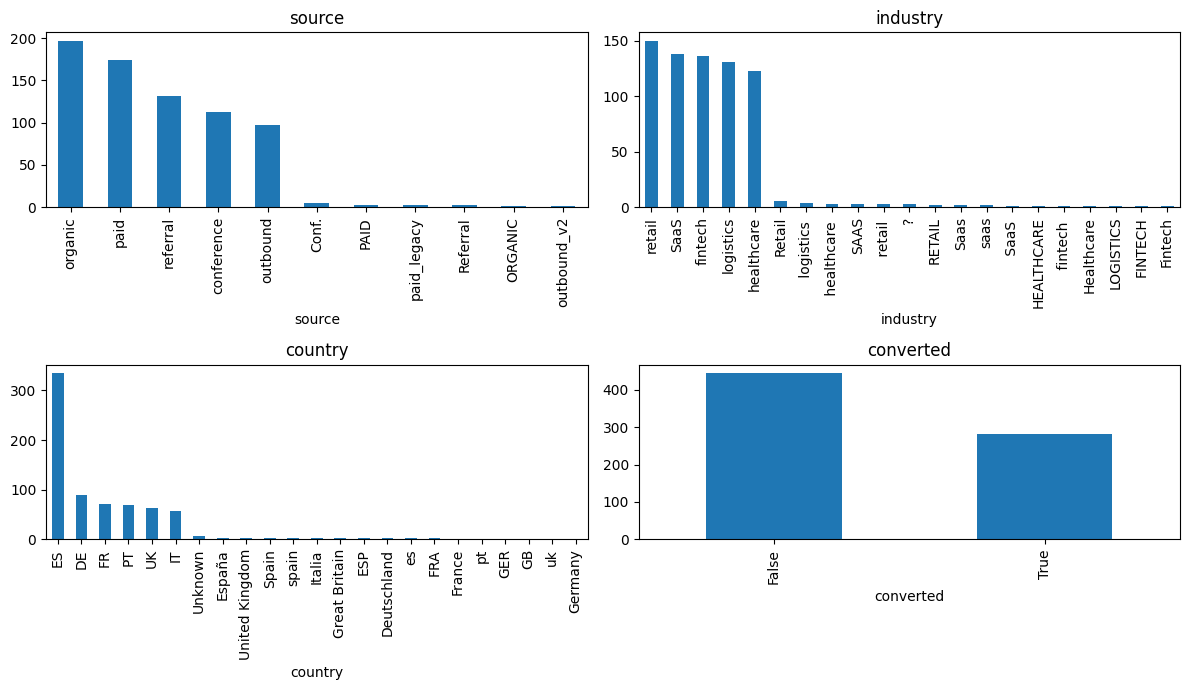

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
df["source"].value_counts().plot(kind="bar", ax=axes[0, 0], title="source")
df["industry"].value_counts().plot(kind="bar", ax=axes[0, 1], title="industry")
df["country"].value_counts().plot(kind="bar", ax=axes[1, 0], title="country")
df["converted"].value_counts().plot(kind="bar", ax=axes[1, 1], title="converted")
plt.tight_layout()
plt.show()


## Cómo varía la conversión

Esto es la pregunta de negocio principal: ¿qué hace que un lead convierta?


In [18]:
by_source = df.groupby("source")["converted"].mean().sort_values(ascending=False)
by_industry = df.groupby("industry")["converted"].mean().sort_values(ascending=False)
print("Tasa de conversión por source:")
print(by_source.round(3).to_string())
print("\nTasa de conversión por industria:")
print(by_industry.round(3).to_string())


Tasa de conversión por source:
source
outbound_v2    1.000
paid           0.592
outbound       0.474
conference     0.460
referral       0.402
PAID           0.333
paid_legacy    0.333
organic        0.132
Conf.          0.000
ORGANIC        0.000
Referral       0.000

Tasa de conversión por industria:
industry
 SaaS           1.000
HEALTHCARE      1.000
 healthcare     0.667
Retail          0.600
 logistics      0.500
RETAIL          0.500
retail          0.440
SaaS            0.406
logistics       0.382
fintech         0.353
healthcare      0.350
?               0.333
SAAS            0.333
 retail         0.000
 fintech        0.000
FINTECH         0.000
Fintech         0.000
Healthcare      0.000
LOGISTICS       0.000
Saas            0.000
saas            0.000


## Distribución de tamaño y ACV

`company_size` y `quoted_acv_eur` son log-normales. Visualízalos en escala log para que se entiendan.


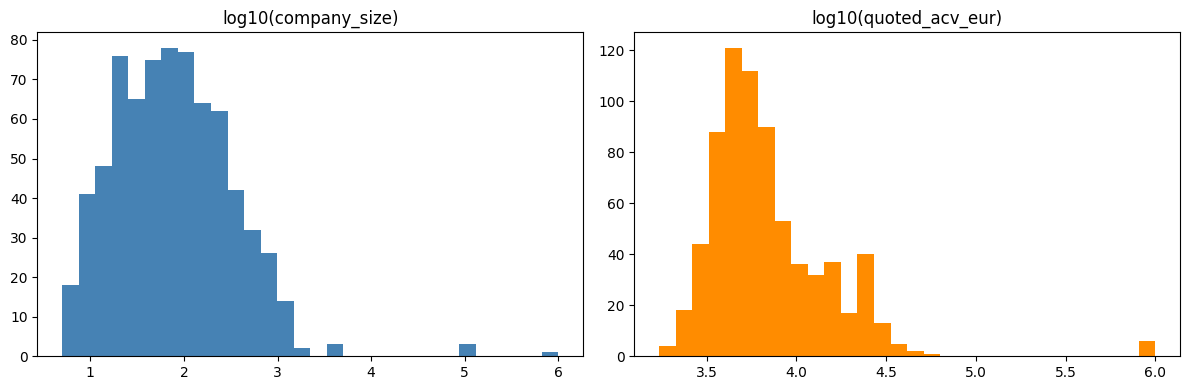

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log10(df["company_size"][df["company_size"] > 0]), bins=30, color="steelblue")
axes[0].set_title("log10(company_size)")
axes[1].hist(np.log10(df["quoted_acv_eur"][df["quoted_acv_eur"] > 0]), bins=30, color="darkorange")
axes[1].set_title("log10(quoted_acv_eur)")
plt.tight_layout()
plt.show()

## Estructura temporal

Los `signup_date` cubren 24 meses con tendencia y estacionalidad plantadas. Veámoslo.


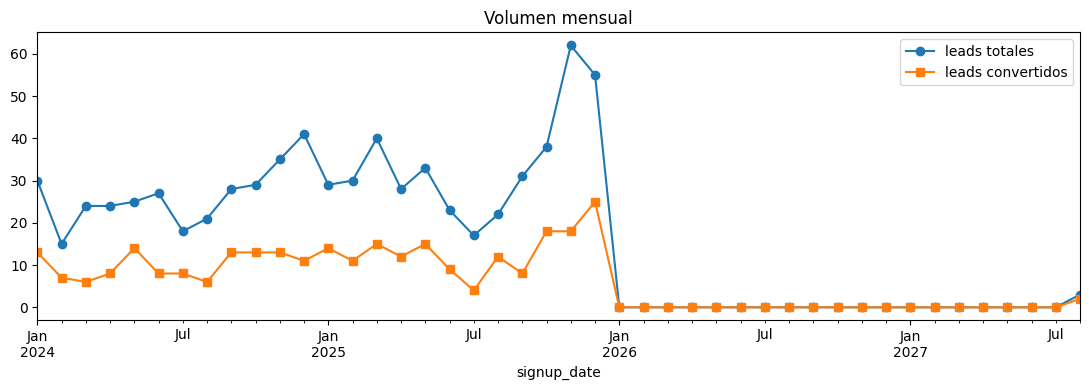

In [20]:
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce", format="mixed")
monthly = df.set_index("signup_date").resample("MS").size()
monthly_conv = df[df["converted"]].set_index("signup_date").resample("MS").size().reindex(monthly.index, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, label="leads totales", marker="o")
monthly_conv.plot(ax=ax, label="leads convertidos", marker="s")
ax.set_title("Volumen mensual")
ax.legend()
plt.tight_layout()
plt.show()

## Echa un vistazo a las descripciones

Esto es lo único que verá el LLM en modo zero-shot durante S2. Lee 5-10 ejemplos para hacerte una idea de qué señal hay (y qué señal NO hay) en el texto.


In [21]:
for _, row in df.sample(8, random_state=0).iterrows():
    print(f"[{row['converted']}] {row['company_description']}")


[False] pequeña jugador de SaaS en DE, ciclo de compra corto.
[False] Small SaaS company in GB, fast decision cycle, looking to close in weeks.
[True] Corporación del sector fintech con presencia en varios países, ciclo de compra largo y comité formal.
[False] healthcare SMB exploring options, no budget allocated yet, comparing free alternatives.
[True] pequeña jugador de retail en DE, ciclo de compra corto.
[False] Empresa de SaaS pequeña en PT, equipo joven y decide rápido.
[True] Startup de retail con unos 41 empleados, busca cerrar trato en semanas.
[False] Pyme de retail en fase exploratoria, sin presupuesto asignado todavía.


## La verdad oculta

El generador plantó tres arquetipos. Están guardados en `lead_segment_truth`. **No** los uses como feature en clasificación o regresión — sí los usaremos para evaluar la calidad del clustering en S1.


In [22]:
df["lead_segment_truth"].value_counts()


lead_segment_truth
tire_kicker    296
quick_mover    261
strategic      171
Name: count, dtype: int64

In [23]:
df.groupby("lead_segment_truth")[["company_size", "n_meetings", "response_time_hours", "quoted_acv_eur", "converted"]].mean().round(2)


,company_size,n_meetings,response_time_hours,quoted_acv_eur,converted
lead_segment_truth,,,,,
quick_mover,1172.03,2.54,29.18,12815.43,0.66
strategic,546.11,6.01,27.55,19168.08,0.53
tire_kicker,3488.67,0.53,85.41,19018.61,0.07


## Encuentra el desorden

Antes de modelar nada, hay que limpiar. Esto te lo encuentras en cualquier dataset real. Algunas líneas para pillar la idea — si ves muchas variantes raras, no estás loco, están plantadas.


In [24]:
print('industry — value_counts (con NaN):')
print(df['industry'].value_counts(dropna=False).head(15))
print()
print('country — value_counts (con NaN):')
print(df['country'].value_counts(dropna=False).head(15))
print()
print('source — value_counts:')
print(df['source'].value_counts(dropna=False).head(15))


industry — value_counts (con NaN):
industry
retail          150
SaaS            138
fintech         136
logistics       131
healthcare      123
NaN              16
Retail            5
 logistics        4
 healthcare       3
SAAS              3
 retail           3
?                 3
RETAIL            2
Saas              2
saas              2
Name: count, dtype: int64

country — value_counts (con NaN):
country
ES                335
DE                 89
FR                 71
PT                 70
UK                 64
IT                 58
NaN                 7
Unknown             6
España              3
United Kingdom      3
Spain               2
spain               2
Italia              2
Great Britain       2
ESP                 2
Name: count, dtype: int64

source — value_counts:
source
organic        197
paid           174
referral       132
conference     113
outbound        97
Conf.            5
PAID             3
paid_legacy      3
Referral         2
ORGANIC          1
outbound_v

In [25]:
print('Tipos por columna:')
print(df.dtypes.to_string())
print()
print('demo_requested — primeros 10 valores únicos:')
print(list(df['demo_requested'].unique()[:10]))
print()
print('Filas duplicadas exactas:', df.duplicated().sum())
print('lead_id duplicados:      ', df['lead_id'].duplicated().sum())
print()
print('NaN por columna:')
print(df.isna().sum().sort_values(ascending=False).to_string())


Tipos por columna:
lead_id                                str
company_name                           str
industry                               str
company_size                         int64
country                                str
signup_date                 datetime64[us]
source                                 str
demo_requested                         str
emails_opened                      float64
response_time_hours                float64
n_meetings                           int64
decision_maker_contacted              bool
quoted_acv_eur                     float64
company_description                    str
converted                             bool
converted_within_days              float64
lead_segment_truth                     str

demo_requested — primeros 10 valores únicos:
['True', 'False', 'yes', 'true', 'false', 'N', 'Y', 'no', '0', '1']

Filas duplicadas exactas: 10
lead_id duplicados:       10

NaN por columna:
converted_within_days       452
industry                   

## 🚀 Si te quedas con ganas

1. Encuentra los leads de prueba (`TEST LEAD - DELETE`, `asdfasdf`, etc.). ¿Cuántos hay y dónde están?
2. Calcula el lifetime value medio por arquetipo (suponiendo `quoted_acv_eur` como anual). ¿Quién es realmente el más rentable?
3. ¿Hay diferencias claras de `response_time_hours` por `country`? ¿Por `source`? Cuidado con los outliers (`5000h`).
4. Construye un heatmap `industry × country` con la tasa de conversión. ¿Hay celdas vacías?
5. Mira `converted_within_days` solo en convertidos. ¿La distribución se parece más a una exponencial o a una log-normal? Pista: histograma + log-scale.
6. Cuenta cuántas descripciones están en inglés. ¿Cómo lo detectarías sin leer cada una?
7. Encuentra los `signup_date` futuros. ¿Qué política aplicarías?
